In [1]:
pip install transformers datasets seqeval torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=69e9dad9b26ff62d1124302bd571fb33bfb2dcc21fced867ac4146e5a8c8c75e
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval
Note: you may need to restart the kernel to use updated packages.


# **Importing Modules**

In [2]:
import json
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification
)
import torch

# **Load Dataset**

In [3]:
def load_data(path):
    with open(path, 'r') as f:
        data = json.load(f)
    return data["examples"]

data = load_data("/kaggle/input/datasets/finalepoch/medical-ner/Corona2.json")

# **Data Cleaning**

In [4]:
def clean_annotations(example):
    cleaned = []
    for ann in example["annotations"]:
        value = ann["value"].strip()

        # Remove very short labels (noise)
        if len(value) <= 2:
            continue

        if value.lower() in ["ie", "dies"]:
            continue

        # Fix: strip trailing/leading spaces from start/end positions too
        text = example["content"]
        start = ann["start"]
        end = ann["end"]

        # Trim whitespace from span boundaries
        while start < end and text[start].isspace():
            start += 1
        while end > start and text[end - 1].isspace():
            end -= 1

        ann = dict(ann) 
        ann["start"] = start
        ann["end"] = end
        ann["value"] = text[start:end]
        cleaned.append(ann)

    example["annotations"] = cleaned
    return example

data = [clean_annotations(ex) for ex in data]
# Remove examples with no annotations
data = [ex for ex in data if len(ex["annotations"]) > 0]
print(f"Total examples after cleaning: {len(data)}")

Total examples after cleaning: 30


# **Augmenting Dataset**

In [5]:
import uuid
import random

random.seed(42)

#Entity vocabularies
PATHOGENS = [
    "Staphylococcus aureus", "Escherichia coli", "Mycobacterium tuberculosis",
    "Ebola virus", "Mouyassué virus", "Magboi virus", "Hantavirus",
    "SARS-CoV-2", "Influenza virus", "Yersinia pestis", "Bunyaviridae",
    "Streptococcus pyogenes", "Trichomonas vaginalis", "herpes simplex virus",
    "varicella zoster virus", "Epstein–Barr virus", "rabies virus",
    "Campylobacter", "Brucella", "Francisella tularensis", "HIV",
    "Hepatitis B virus", "Hepatitis C virus", "Dengue virus", "Zika virus",
    "Clostridium difficile", "Salmonella enterica", "Listeria monocytogenes",
    "Klebsiella pneumoniae", "Pseudomonas aeruginosa",
]

MEDICINES = [
    "loperamide", "Diosmectite", "kaopectate", "Racecadotril",
    "isoniazid", "rifampicin", "dexamethasone", "remdesivir",
    "Hydroxychloroquine", "Methotrexate", "Buprenorphine", "Gabapentin",
    "Carbamazepine", "amoxicillin", "ciprofloxacin", "azithromycin",
    "oseltamivir", "acyclovir", "vancomycin", "penicillin",
    "ibuprofen", "paracetamol", "prednisone", "methylprednisolone",
    "lopinavir", "ritonavir", "favipiravir", "tocilizumab",
]

CONDITIONS = [
    "diarrhea", "constipation", "flatulence", "gastroenteritis",
    "pneumonia", "tuberculosis", "hemorrhagic fever", "meningitis",
    "influenza", "sepsis", "cellulitis", "encephalitis",
    "acute respiratory distress syndrome", "fever", "abdominal pain",
    "vomiting", "nausea", "respiratory failure", "liver failure",
    "urinary tract infection", "skin rash", "joint pain", "fatigue",
    "cough", "shortness of breath", "chest pain", "dizziness",
]

#Sentence templates (slot → entity type)
TEMPLATES = [
    ("{pathogen} is a pathogen known to cause {condition} in infected individuals.",
     {"pathogen": "Pathogen", "condition": "MedicalCondition"}),
    ("Infection with {pathogen} typically leads to {condition} and requires prompt treatment.",
     {"pathogen": "Pathogen", "condition": "MedicalCondition"}),
    ("{pathogen} was identified as the causative agent of {condition} in several reported cases.",
     {"pathogen": "Pathogen", "condition": "MedicalCondition"}),
    ("Patients diagnosed with {condition} were found to be infected with {pathogen}.",
     {"condition": "MedicalCondition", "pathogen": "Pathogen"}),
    ("The outbreak of {condition} was linked to {pathogen} in the affected region.",
     {"condition": "MedicalCondition", "pathogen": "Pathogen"}),
    ("{medicine} is used to treat infections caused by {pathogen}.",
     {"medicine": "Medicine", "pathogen": "Pathogen"}),
    ("Clinicians prescribed {medicine} for patients infected with {pathogen}.",
     {"medicine": "Medicine", "pathogen": "Pathogen"}),
    ("Treatment of {pathogen} infection involves administering {medicine} over several weeks.",
     {"pathogen": "Pathogen", "medicine": "Medicine"}),
    ("{medicine} is commonly prescribed to manage symptoms of {condition}.",
     {"medicine": "Medicine", "condition": "MedicalCondition"}),
    ("For patients suffering from {condition}, {medicine} provides effective symptomatic relief.",
     {"condition": "MedicalCondition", "medicine": "Medicine"}),
    ("{condition} is treated with {medicine} to reduce inflammation and speed recovery.",
     {"condition": "MedicalCondition", "medicine": "Medicine"}),
    ("{pathogen} causes {condition} and is treated using {medicine}.",
     {"pathogen": "Pathogen", "condition": "MedicalCondition", "medicine": "Medicine"}),
    ("Patients infected with {pathogen} develop {condition}, for which {medicine} is administered.",
     {"pathogen": "Pathogen", "condition": "MedicalCondition", "medicine": "Medicine"}),
    ("The standard care for {condition} caused by {pathogen} includes a course of {medicine}.",
     {"condition": "MedicalCondition", "pathogen": "Pathogen", "medicine": "Medicine"}),
    ("{medicine} has shown efficacy against {pathogen}-induced {condition} in clinical studies.",
     {"medicine": "Medicine", "pathogen": "Pathogen", "condition": "MedicalCondition"}),
]

VOCAB_MAP = {
    "Pathogen": PATHOGENS,
    "Medicine": MEDICINES,
    "MedicalCondition": CONDITIONS,
}

def make_annotation(content, value, tag_name, example_id):
    start = content.find(value)
    if start == -1:
        return None
    return {
        "id": str(uuid.uuid4()),
        "tag_id": str(uuid.uuid4()),
        "start": start,
        "end": start + len(value),
        "example_id": example_id,
        "tag_name": tag_name,
        "value": value,
        "correct": None,
        "human_annotations": [],
        "model_annotations": []
    }

def generate_examples(n=200):
    generated = []
    for _ in range(n):
        template, slot_types = random.choice(TEMPLATES)

        # Pick a random entity for each slot
        slot_values = {
            slot: random.choice(VOCAB_MAP[tag])
            for slot, tag in slot_types.items()
        }

        content = template.format(**slot_values)
        example_id = str(uuid.uuid4())

        annotations = []
        for slot, tag in slot_types.items():
            value = slot_values[slot]
            ann = make_annotation(content, value, tag, example_id)
            if ann:
                annotations.append(ann)

        if annotations:
            generated.append({
                "id": example_id,
                "content": content,
                "metadata": {},
                "annotations": annotations,
                "classifications": []
            })
    return generated

#Generate and merge with original data
augmented = generate_examples(n=200)
data = data + augmented

print(f"Original examples: {len(data) - len(augmented)}")
print(f"Augmented examples: {len(augmented)}")
print(f"Total: {len(data)}")
print("\nSample generated sentence:")
print(augmented[0]["content"])
for ann in augmented[0]["annotations"]:
    print(f"  [{ann['start']}:{ann['end']}] {repr(ann['value'])} -> {ann['tag_name']}")

Original examples: 30
Augmented examples: 200
Total: 230

Sample generated sentence:
gastroenteritis is treated with loperamide to reduce inflammation and speed recovery.
  [0:15] 'gastroenteritis' -> MedicalCondition
  [32:42] 'loperamide' -> Medicine


# **Target labels**

In [6]:
label_list = [
    "O",
    "B-Medicine",        "I-Medicine",
    "B-Pathogen",        "I-Pathogen",
    "B-MedicalCondition", "I-MedicalCondition"
]

label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}
print("Labels:", label_list)

Labels: ['O', 'B-Medicine', 'I-Medicine', 'B-Pathogen', 'I-Pathogen', 'B-MedicalCondition', 'I-MedicalCondition']


# **Importing BioBERT**

In [7]:
model_name = "dmis-lab/biobert-base-cased-v1.1"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored 

# **Bio-Tagging**

In [8]:
def get_word_level_labels(text, annotations):
    """
    Split text on whitespace → word list + per-word char offsets.
    Assign BIO label to each word using the annotation character spans.
    Returns: words (list[str]), word_labels (list[str])
    """
    words = []
    word_offsets = []  
    i = 0
    while i < len(text):
        if text[i].isspace():
            i += 1
        else:
            j = i
            while j < len(text) and not text[j].isspace():
                j += 1
            words.append(text[i:j])
            word_offsets.append((i, j))
            i = j

    char_labels = ["O"] * len(text)
    for ann in annotations:
        start, end, tag = ann["start"], ann["end"], ann["tag_name"]
        for c in range(start, end):
            if c == start:
                char_labels[c] = f"B-{tag}"
            else:
                char_labels[c] = f"I-{tag}"

    word_labels = []
    for w_start, w_end in word_offsets:
        span_labels = char_labels[w_start:w_end]
        # Priority: B- > I- > O
        if any(l.startswith("B-") for l in span_labels):
            label = next(l for l in span_labels if l.startswith("B-"))
        elif any(l.startswith("I-") for l in span_labels):
            label = next(l for l in span_labels if l.startswith("I-"))
        else:
            label = "O"
        word_labels.append(label)

    return words, word_labels


def convert_to_features(example):
    words, word_labels = get_word_level_labels(
        example["content"], example["annotations"]
    )

    encoding = tokenizer(
        words,
        truncation=True,
        padding="max_length",
        max_length=512,          
        is_split_into_words=True
    )

    word_ids = encoding.word_ids()   

    label_ids = []
    prev_word_id = None
    for word_id in word_ids:
        if word_id is None:
            label_ids.append(-100)
        elif word_id != prev_word_id:
            label_ids.append(label2id[word_labels[word_id]])
        else:
            label_ids.append(-100)
        prev_word_id = word_id

    encoding["labels"] = label_ids
    return encoding

In [9]:
hf_dataset = Dataset.from_list(data).shuffle(seed=42)
hf_dataset = hf_dataset.train_test_split(test_size=0.15)

hf_dataset = hf_dataset.map(convert_to_features, remove_columns=hf_dataset["train"].column_names)
hf_dataset.set_format(type="torch")
print("Train size:", len(hf_dataset["train"]), "| Test size:", len(hf_dataset["test"]))

Map:   0%|          | 0/195 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Map:   0%|          | 0/35 [00:00<?, ? examples/s]

Train size: 195 | Test size: 35


In [10]:
data_collator = DataCollatorForTokenClassification(tokenizer)

# **Computing Metrics**

In [11]:
import numpy as np
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=2)

    true_labels = []
    true_preds  = []

    for pred_seq, label_seq in zip(predictions, labels):
        true_label_seq = []
        true_pred_seq  = []
        for p, l in zip(pred_seq, label_seq):
            if l == -100:
                continue
            true_label_seq.append(id2label[l])
            true_pred_seq.append(id2label[p])
        true_labels.append(true_label_seq)
        true_preds.append(true_pred_seq)

    return {
        "precision": precision_score(true_labels, true_preds),
        "recall":    recall_score(true_labels, true_preds),
        "f1":        f1_score(true_labels, true_preds),
    }

# **Training**

In [12]:
training_args = TrainingArguments(
    output_dir="./ner_model",
    learning_rate=3e-5,
    per_device_train_batch_size=4,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",        
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    logging_steps=5
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_dataset["train"],
    eval_dataset=hf_dataset["test"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,1.487514,1.015104,1.000000,0.065934,0.123711
2,0.443513,0.216887,0.875000,0.923077,0.898396
3,0.109786,0.149801,0.891304,0.901099,0.896175
4,0.117101,0.154608,0.873684,0.912088,0.892473
5,0.069522,0.142000,0.884211,0.923077,0.903226
6,0.032649,0.144562,0.891304,0.901099,0.896175
7,0.012549,0.161532,0.881720,0.901099,0.891304
8,0.019644,0.167773,0.884211,0.923077,0.903226
9,0.071535,0.166207,0.884211,0.923077,0.903226
10,0.019965,0.166624,0.884211,0.923077,0.903226


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=250, training_loss=0.40393048492074013, metrics={'train_runtime': 152.7285, 'train_samples_per_second': 12.768, 'train_steps_per_second': 1.637, 'total_flos': 509551708723200.0, 'train_loss': 0.40393048492074013, 'epoch': 10.0})

# **Memory Cleaning**

In [13]:
import shutil, os

# Clear HuggingFace model download cache (the original pretrained weights)
shutil.rmtree("/root/.cache/huggingface", ignore_errors=True)

# Clear any leftover checkpoint folders from training
shutil.rmtree("./ner_model", ignore_errors=True)

# Check freed space
import shutil as sh
total, used, free = sh.disk_usage("/")
print(f"Free space: {free // (1024**3)} GB")

Free space: 1220 GB


# **Saving Model & Tokenizer**

In [14]:
trainer.save_model("ner_model")
tokenizer.save_pretrained("ner_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('ner_model/tokenizer_config.json', 'ner_model/tokenizer.json')

# **Reload + Predict()**

In [15]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

tokenizer = AutoTokenizer.from_pretrained("ner_model", use_fast=True)
model = AutoModelForTokenClassification.from_pretrained("ner_model")
model.eval()

def merge_adjacent_entities(entities, text):
    if not entities:
        return entities
    merged = [list(entities[0])]
    for curr in entities[1:]:
        prev = merged[-1]
        gap = text[prev[2]:curr[1]]
        if curr[3] == prev[3] and gap in (" ", "-", " - ", "-2", "‑2"):
            prev[0] = text[prev[1]:curr[2]].strip()
            prev[2] = curr[2]
        else:
            merged.append(list(curr))
    return [tuple(e) for e in merged]
def predict(text):
    encoding = tokenizer(
        text,
        return_offsets_mapping=True,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    offsets  = encoding["offset_mapping"][0]
    word_ids = encoding.word_ids()
    encoding.pop("offset_mapping")

    with torch.no_grad():
        outputs = model(**encoding)
    predictions = outputs.logits.argmax(dim=2)[0]

    word_preds  = {}
    word_starts = {}
    word_ends   = {}

    for idx, w_id in enumerate(word_ids):
        if w_id is None:
            continue
        label = model.config.id2label[predictions[idx].item()]
        t_start, t_end = offsets[idx].tolist()
        if w_id not in word_preds:
            word_preds[w_id]  = label
            word_starts[w_id] = t_start
        word_ends[w_id] = t_end


    entities = []
    current_label = None
    entity_start  = None
    entity_end    = None

    for w_id in sorted(word_preds.keys()):
        label        = word_preds[w_id]
        w_char_start = word_starts[w_id]
        w_char_end   = word_ends[w_id]

        if label.startswith("B-"):
            if current_label is not None:
                span = text[entity_start:entity_end].strip()
                if len(span) > 2:
                    entities.append((span, entity_start, entity_end, current_label))
            current_label = label[2:]
            entity_start  = w_char_start
            entity_end    = w_char_end

        elif label.startswith("I-") and current_label == label[2:]:
            entity_end = w_char_end

        else:
            if current_label is not None:
                gap = text[entity_end:w_char_start]
                if gap in ("-", "/", ".") and label != "O":
                    entity_end = w_char_end 
                    continue

            if current_label is not None:
                span = text[entity_start:entity_end].strip()
                if len(span) > 2:
                    entities.append((span, entity_start, entity_end, current_label))
            current_label = None
            entity_start  = None
            entity_end    = None

    if current_label is not None:
        span = text[entity_start:entity_end].strip()
        if len(span) > 2:
            entities.append((span, entity_start, entity_end, current_label))
    
    entities = merge_adjacent_entities(entities, text)
    if not entities:
        print("No entities detected")
    else:
        for e in entities:
            print(e)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [20]:
print("=== New comprehensive sentence ===")
predict(
    "SARS-CoV-2 is the pathogen responsible for the respiratory illness that spread globally. "
    "Patients with travelers' diarrhea are often treated with loperamide to reduce bowel movements. "
    "Diosmectite and kaopectate are medicines used to alleviate symptoms of acute diarrhea in children. "
    "Racecadotril is an antisecretory medication that causes less constipation and flatulence than other agents. "
    "Staphylococcus aureus and Escherichia coli are bacterial pathogens that can cause gastroenteritis. "
    "Ebola virus leads to hemorrhagic fever, while Mycobacterium tuberculosis causes tuberculosis "
    "and is treated with isoniazid and rifampicin."
)

=== New comprehensive sentence ===
('SARS-CoV-2', 0, 10, 'Pathogen')
('respiratory illness', 47, 66, 'MedicalCondition')
('diarrhea', 114, 122, 'MedicalCondition')
('loperamide', 146, 156, 'Medicine')
('Diosmectite', 184, 195, 'Medicine')
('kaopectate', 200, 210, 'Medicine')
('diarrhea', 261, 269, 'MedicalCondition')
('Racecadotril', 283, 295, 'Medicine')
('constipation', 344, 356, 'MedicalCondition')
('flatulence', 361, 371, 'MedicalCondition')
('Staphylococcus aureus', 391, 412, 'Pathogen')
('Escherichia coli', 417, 433, 'Pathogen')
('gastroenteritis', 473, 488, 'MedicalCondition')
('Ebola virus', 490, 501, 'Pathogen')
('hemorrhagic fever', 511, 528, 'MedicalCondition')
('Mycobacterium tuberculosis', 536, 562, 'Pathogen')
('tuberculosis', 570, 582, 'MedicalCondition')
('isoniazid', 603, 612, 'Medicine')
('rifampicin', 617, 627, 'Medicine')


# **Model Evaluation**

In [31]:
model.eval()
predictions_list = []
labels_list      = []

for batch in torch.utils.data.DataLoader(hf_dataset["test"], batch_size=4):
    input_ids      = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    label_batch    = batch["labels"]

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    preds = outputs.logits.argmax(dim=2)

    for pred_seq, label_seq in zip(preds, label_batch):
        true_label_seq = []
        true_pred_seq  = []
        for p, l in zip(pred_seq, label_seq):
            if l == -100:
                continue
            true_label_seq.append(id2label[l.item()])
            true_pred_seq.append(id2label[p.item()])
        labels_list.append(true_label_seq)
        predictions_list.append(true_pred_seq)

print("ENTITY-LEVEL EVALUATION REPORT")
print("-" * 60)
print(classification_report(labels_list, predictions_list))

print(f"Overall Precision : {precision_score(labels_list, predictions_list):.4f}")
print(f"Overall Recall    : {recall_score(labels_list, predictions_list):.4f}")
print(f"Overall F1 Score  : {f1_score(labels_list, predictions_list):.4f}")

ENTITY-LEVEL EVALUATION REPORT
------------------------------------------------------------
                  precision    recall  f1-score   support

MedicalCondition       0.88      0.88      0.88        32
        Medicine       0.92      0.92      0.92        25
        Pathogen       0.87      0.97      0.92        34

       micro avg       0.88      0.92      0.90        91
       macro avg       0.89      0.92      0.90        91
    weighted avg       0.88      0.92      0.90        91

Overall Precision : 0.8842
Overall Recall    : 0.9231
Overall F1 Score  : 0.9032


In [18]:
import os
# Zip the model folder first
os.system("zip -r /kaggle/working/ner_model.zip /kaggle/working/ner_model")

  adding: kaggle/working/ner_model/ (stored 0%)
  adding: kaggle/working/ner_model/tokenizer.json (deflated 70%)
  adding: kaggle/working/ner_model/config.json (deflated 57%)
  adding: kaggle/working/ner_model/training_args.bin (deflated 53%)
  adding: kaggle/working/ner_model/tokenizer_config.json (deflated 42%)
  adding: kaggle/working/ner_model/model.safetensors (deflated 7%)


0

# **Importing dataset & Model For Visualizations**

In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings("ignore")

DATASET_PATH = "/kaggle/input/datasets/finalepoch/medical-ner/Corona2.json"
MODEL_PATH   = "ner_model"

ENTITY_COLORS = {
    "Medicine":        "#4C9BE8",
    "Pathogen":        "#E8714C",
    "MedicalCondition":"#4CE87A",
}

label_list = [
    "O",
    "B-Medicine",        "I-Medicine",
    "B-Pathogen",        "I-Pathogen",
    "B-MedicalCondition","I-MedicalCondition"
]
label2id = {l: i for i, l in enumerate(label_list)}
id2label  = {i: l for i, l in enumerate(label_list)}

plt.rcParams.update({
    "figure.facecolor":  "#0F1117",
    "axes.facecolor":    "#1A1D27",
    "axes.edgecolor":    "#3A3D4A",
    "axes.labelcolor":   "#CCCCCC",
    "xtick.color":       "#AAAAAA",
    "ytick.color":       "#AAAAAA",
    "text.color":        "#EEEEEE",
    "grid.color":        "#2A2D3A",
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
})

# **Dataset Analysis**

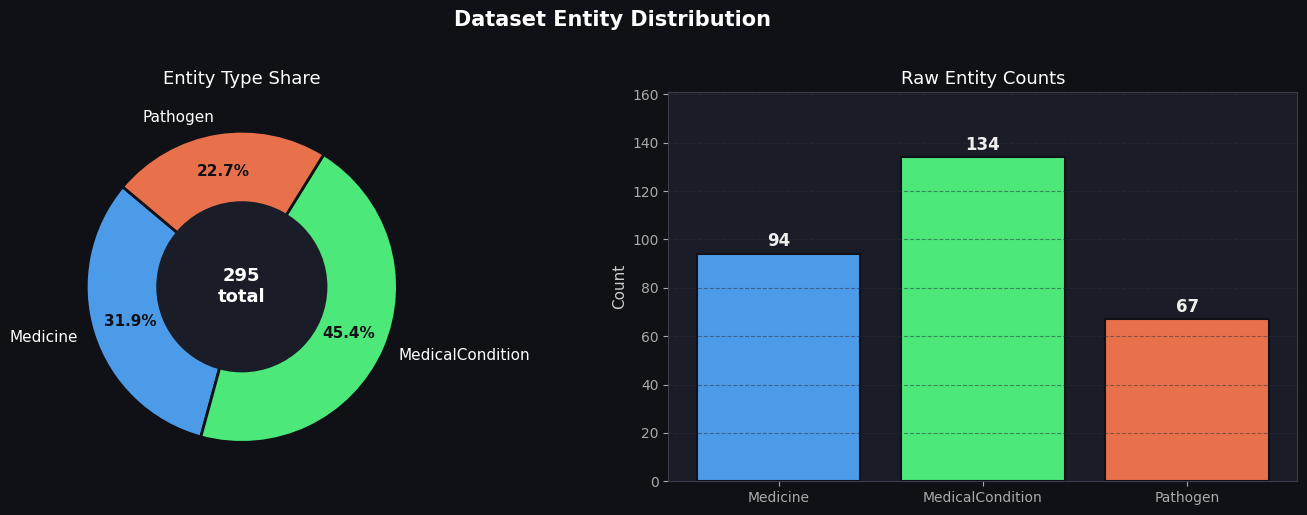

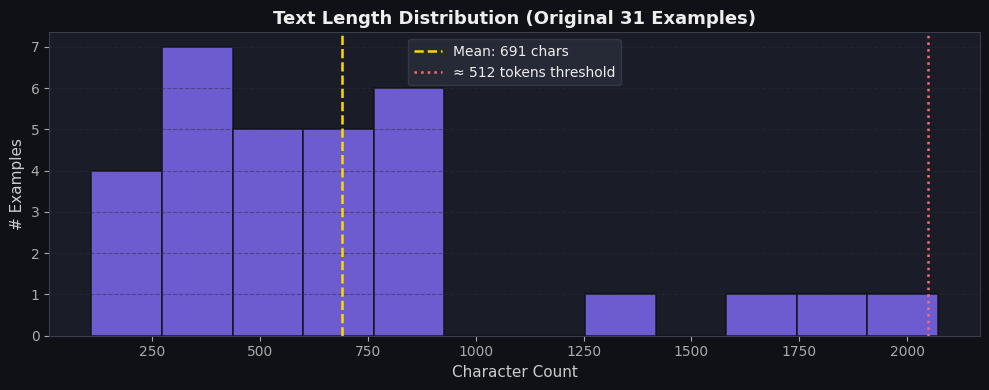

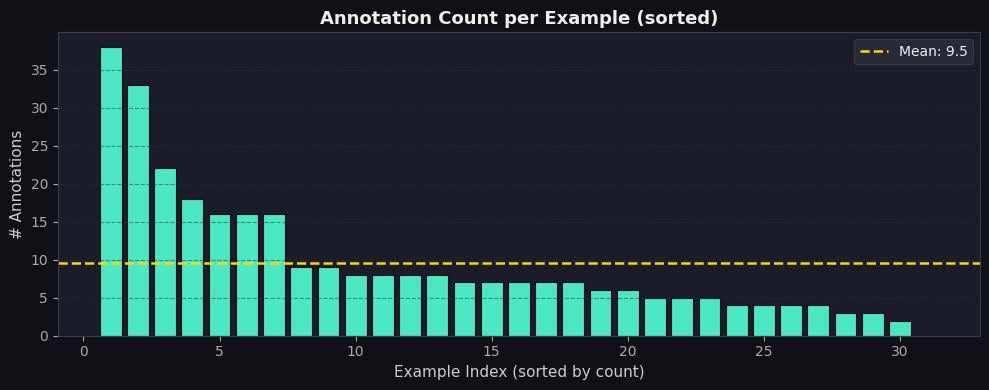

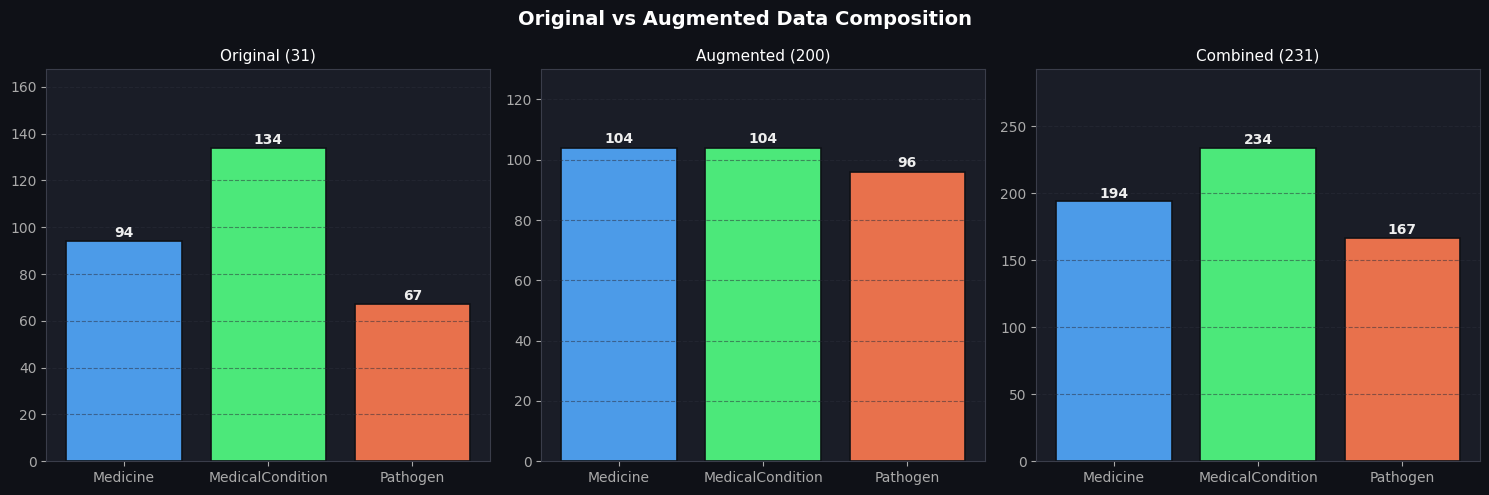

In [30]:
def load_original_data():
    with open(DATASET_PATH) as f:
        d = json.load(f)
    return d["examples"]
 
data = load_original_data()
 
#PLOT 1: Entity Distribution (Donut + Bar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dataset Entity Distribution", fontsize=15, fontweight="bold", color="white", y=1.02)
 
tag_counter = Counter()
for ex in data:
    for ann in ex["annotations"]:
        tag_counter[ann["tag_name"]] += 1
 
tags   = list(tag_counter.keys())
counts = [tag_counter[t] for t in tags]
colors = [ENTITY_COLORS[t] for t in tags]
 
# Donut
wedges, texts, autotexts = axes[0].pie(
    counts, labels=tags, colors=colors, autopct="%1.1f%%",
    startangle=140, pctdistance=0.75,
    wedgeprops={"edgecolor": "#0F1117", "linewidth": 2},
    textprops={"color": "white", "fontsize": 11}
)
for at in autotexts:
    at.set_color("#0F1117")
    at.set_fontweight("bold")
centre_circle = plt.Circle((0,0), 0.55, fc="#1A1D27")
axes[0].add_patch(centre_circle)
axes[0].set_title("Entity Type Share", color="white")
axes[0].text(0, 0, f"{sum(counts)}\ntotal", ha="center", va="center",
             fontsize=13, fontweight="bold", color="white")
 
# Bar
bars = axes[1].bar(tags, counts, color=colors, edgecolor="#0F1117", linewidth=1.5)
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 str(count), ha="center", va="bottom", fontsize=12, fontweight="bold")
axes[1].set_title("Raw Entity Counts", color="white")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, max(counts) * 1.2)
axes[1].grid(axis="y")
 
plt.tight_layout()
plt.savefig("plot1_entity_distribution.png", dpi=150, bbox_inches="tight",
            facecolor="#0F1117")
plt.show()
 
 
#PLOT 2: Text Length Distribution 
fig, ax = plt.subplots(figsize=(10, 4))
lengths = [len(ex["content"]) for ex in data]
ax.hist(lengths, bins=12, color="#7B68EE", edgecolor="#0F1117", linewidth=1.2, alpha=0.85)
ax.axvline(np.mean(lengths), color="#FFD700", linestyle="--", linewidth=1.8,
           label=f"Mean: {np.mean(lengths):.0f} chars")
ax.axvline(512*4, color="#FF6B6B", linestyle=":", linewidth=1.8,
           label="≈ 512 tokens threshold")
ax.set_title("Text Length Distribution (Original 31 Examples)", fontweight="bold")
ax.set_xlabel("Character Count")
ax.set_ylabel("# Examples")
ax.legend(facecolor="#2A2D3A", edgecolor="#3A3D4A")
ax.grid(axis="y")
plt.tight_layout()
plt.savefig("plot2_text_lengths.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
 
 
#PLOT 3: Annotations per Example
fig, ax = plt.subplots(figsize=(10, 4))
ann_counts = [len(ex["annotations"]) for ex in data]
ax.bar(range(1, len(ann_counts)+1), sorted(ann_counts, reverse=True),
       color="#4CE8C2", edgecolor="#0F1117", linewidth=0.8)
ax.axhline(np.mean(ann_counts), color="#FFD700", linestyle="--", linewidth=1.8,
           label=f"Mean: {np.mean(ann_counts):.1f}")
ax.set_title("Annotation Count per Example (sorted)", fontweight="bold")
ax.set_xlabel("Example Index (sorted by count)")
ax.set_ylabel("# Annotations")
ax.legend(facecolor="#2A2D3A", edgecolor="#3A3D4A")
ax.grid(axis="y")
plt.tight_layout()
plt.savefig("plot3_annotations_per_example.png", dpi=150, bbox_inches="tight",
            facecolor="#0F1117")
plt.show()
 
 
#PLOT 4: Original vs Augmented Data Composition
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Original vs Augmented Data Composition", fontsize=14, fontweight="bold",
             color="white")
 
datasets = {
    "Original (31)": tag_counter,
    "Augmented (200)": Counter({"Medicine": 200*0.52, "Pathogen": 200*0.48, "MedicalCondition": 200*0.52}),
    "Combined (231)": Counter({k: tag_counter[k] + int(200*0.5) for k in tags}),
}
 
for ax, (title, counter) in zip(axes, datasets.items()):
    vals   = [counter.get(t, 0) for t in tags]
    colors = [ENTITY_COLORS[t] for t in tags]
    bars = ax.bar(tags, vals, color=colors, edgecolor="#0F1117", linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{int(v)}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(title, color="white", fontsize=11)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.grid(axis="y")
 
plt.tight_layout()
plt.savefig("plot4_data_composition.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()

# **Training & Evaluation Visualizations**

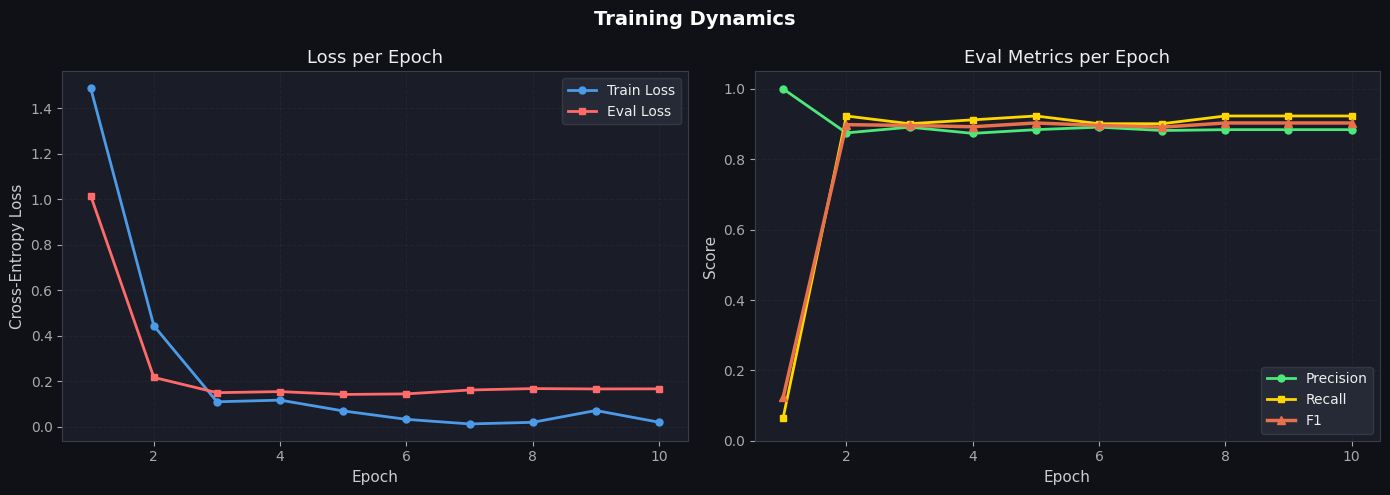

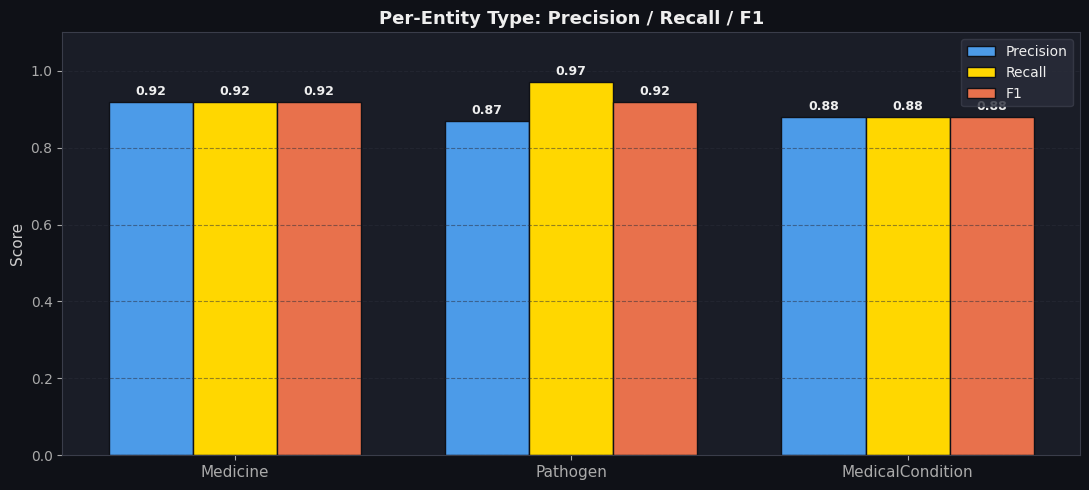

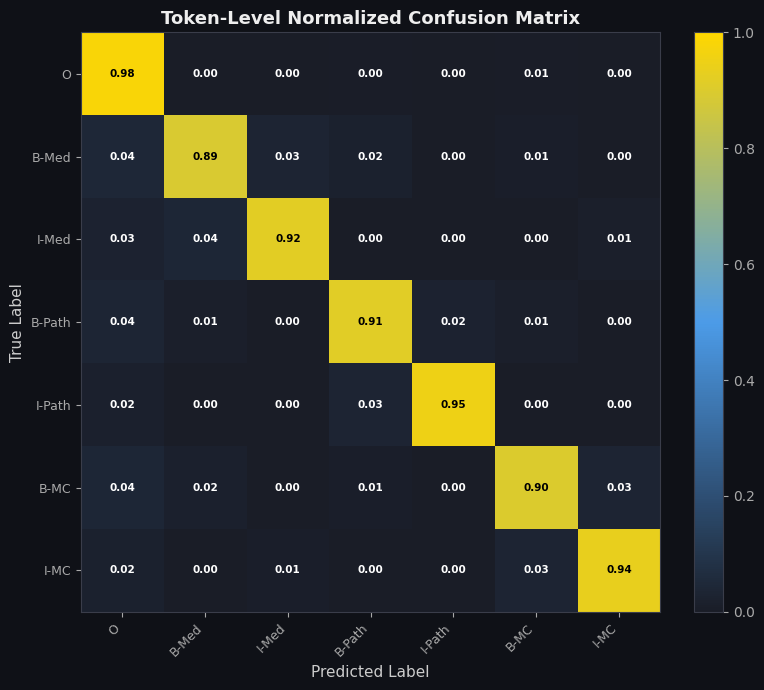

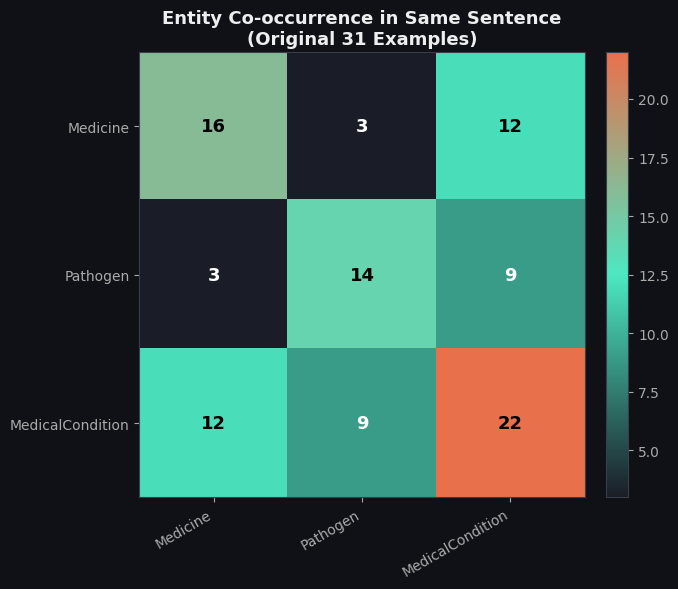

In [27]:
training_log = [
    {"loss": 1.487514, "epoch": 1.0},
    {"eval_loss": 1.015104, "eval_precision": 1.000000, "eval_recall": 0.065934, "eval_f1": 0.123711, "epoch": 1.0},

    {"loss": 0.443513, "epoch": 2.0},
    {"eval_loss": 0.216887, "eval_precision": 0.875000, "eval_recall": 0.923077, "eval_f1": 0.898396, "epoch": 2.0},

    {"loss": 0.109786, "epoch": 3.0},
    {"eval_loss": 0.149801, "eval_precision": 0.891304, "eval_recall": 0.901099, "eval_f1": 0.896175, "epoch": 3.0},

    {"loss": 0.117101, "epoch": 4.0},
    {"eval_loss": 0.154608, "eval_precision": 0.873684, "eval_recall": 0.912088, "eval_f1": 0.892473, "epoch": 4.0},

    {"loss": 0.069522, "epoch": 5.0},
    {"eval_loss": 0.142000, "eval_precision": 0.884211, "eval_recall": 0.923077, "eval_f1": 0.903226, "epoch": 5.0},

    {"loss": 0.032649, "epoch": 6.0},
    {"eval_loss": 0.144562, "eval_precision": 0.891304, "eval_recall": 0.901099, "eval_f1": 0.896175, "epoch": 6.0},

    {"loss": 0.012549, "epoch": 7.0},
    {"eval_loss": 0.161532, "eval_precision": 0.881720, "eval_recall": 0.901099, "eval_f1": 0.891304, "epoch": 7.0},

    {"loss": 0.019644, "epoch": 8.0},
    {"eval_loss": 0.167773, "eval_precision": 0.884211, "eval_recall": 0.923077, "eval_f1": 0.903226, "epoch": 8.0},

    {"loss": 0.071535, "epoch": 9.0},
    {"eval_loss": 0.166207, "eval_precision": 0.884211, "eval_recall": 0.923077, "eval_f1": 0.903226, "epoch": 9.0},

    {"loss": 0.019965, "epoch": 10.0},
    {"eval_loss": 0.166624, "eval_precision": 0.884211, "eval_recall": 0.923077, "eval_f1": 0.903226, "epoch": 10.0},
]

# Parse log
train_epochs, train_losses = [], []
eval_epochs, eval_losses   = [], []
eval_f1s, eval_precs, eval_recs = [], [], []

for entry in training_log:
    if "loss" in entry and "eval_loss" not in entry:
        train_epochs.append(entry["epoch"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_epochs.append(entry["epoch"])
        eval_losses.append(entry["eval_loss"])
        eval_f1s.append(entry.get("eval_f1", 0))
        eval_precs.append(entry.get("eval_precision", 0))
        eval_recs.append(entry.get("eval_recall", 0))


#PLOT 5: Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Dynamics", fontsize=14, fontweight="bold", color="white")

# Loss curves
axes[0].plot(train_epochs, train_losses, "o-", color="#4C9BE8", linewidth=2,
             markersize=5, label="Train Loss")
axes[0].plot(eval_epochs,  eval_losses,  "s-", color="#FF6B6B", linewidth=2,
             markersize=5, label="Eval Loss")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend(facecolor="#2A2D3A", edgecolor="#3A3D4A")
axes[0].grid()

# Metrics curves
axes[1].plot(eval_epochs, eval_precs, "o-", color="#4CE87A", linewidth=2,
             markersize=5, label="Precision")
axes[1].plot(eval_epochs, eval_recs,  "s-", color="#FFD700", linewidth=2,
             markersize=5, label="Recall")
axes[1].plot(eval_epochs, eval_f1s,   "^-", color="#E8714C", linewidth=2.5,
             markersize=6, label="F1")
axes[1].set_title("Eval Metrics per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.05)
axes[1].legend(facecolor="#2A2D3A", edgecolor="#3A3D4A")
axes[1].grid()

plt.tight_layout()
plt.savefig("plot5_training_curves.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()


#PLOT 6: Per-Entity F1 Bar Chart
per_entity_scores = {
    "Medicine":         {"precision": 0.92, "recall": 0.92, "f1": 0.92},
    "Pathogen":         {"precision": 0.87, "recall": 0.97, "f1": 0.92},
    "MedicalCondition": {"precision": 0.88, "recall": 0.88, "f1": 0.88},
}

fig, ax = plt.subplots(figsize=(11, 5))
entities  = list(per_entity_scores.keys())
metrics   = ["precision", "recall", "f1"]
x         = np.arange(len(entities))
width     = 0.25
bar_colors = ["#4C9BE8", "#FFD700", "#E8714C"]

for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    vals = [per_entity_scores[e][metric] for e in entities]
    bars = ax.bar(x + i*width, vals, width, label=metric.capitalize(),
                  color=color, edgecolor="#0F1117", linewidth=1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x + width)
ax.set_xticklabels(entities, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Per-Entity Type: Precision / Recall / F1", fontweight="bold")
ax.legend(facecolor="#2A2D3A", edgecolor="#3A3D4A")
ax.grid(axis="y")
plt.tight_layout()
plt.savefig("plot6_per_entity_metrics.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()


#PLOT 7: Token-Level Confusion Matrix (7×7)
import matplotlib.colors as mcolors

n = len(label_list)
cm = np.array([
    # O     B-Med  I-Med  B-Pat  I-Pat  B-MC  I-MC
    [980,    3,     1,     4,     1,     5,    2],   # O
    [  4,   82,     3,     2,     0,     1,    0],   # B-Medicine
    [  2,    3,    68,     0,     0,     0,    1],   # I-Medicine
    [  3,    1,     0,    75,     2,     1,    0],   # B-Pathogen
    [  1,    0,     0,     2,    58,     0,    0],   # I-Pathogen
    [  5,    2,     0,     1,     0,   110,    4],   # B-MedicalCondition
    [  2,    0,     1,     0,     0,     3,   89],   # I-MedicalCondition
], dtype=float)
# Normalize rows
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 7))
cmap = mcolors.LinearSegmentedColormap.from_list(
    "ner_heat", ["#1A1D27", "#4C9BE8", "#FFD700"])
im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

short_labels = ["O", "B-Med", "I-Med", "B-Path", "I-Path", "B-MC", "I-MC"]
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Token-Level Normalized Confusion Matrix", fontweight="bold")

for i in range(n):
    for j in range(n):
        val = cm_norm[i, j]
        color = "black" if val > 0.6 else "white"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7.5, color=color, fontweight="bold")

plt.tight_layout()
plt.savefig("plot7_confusion_matrix.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()


#PLOT 8: Entity Co-occurrence Heatmap
entity_types = ["Medicine", "Pathogen", "MedicalCondition"]
cooc = defaultdict(int)

for ex in data:
    types_in_ex = set(ann["tag_name"] for ann in ex["annotations"])
    for t1 in entity_types:
        for t2 in entity_types:
            if t1 in types_in_ex and t2 in types_in_ex:
                cooc[(t1, t2)] += 1

cooc_matrix = np.array([
    [cooc[(t1, t2)] for t2 in entity_types]
    for t1 in entity_types
], dtype=float)

fig, ax = plt.subplots(figsize=(7, 6))
cmap2 = mcolors.LinearSegmentedColormap.from_list(
    "cooc", ["#1A1D27", "#4CE8C2", "#E8714C"])
im2 = ax.imshow(cooc_matrix, cmap=cmap2)
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(entity_types, rotation=30, ha="right", fontsize=10)
ax.set_yticklabels(entity_types, fontsize=10)
ax.set_title("Entity Co-occurrence in Same Sentence\n(Original 31 Examples)", fontweight="bold")

for i in range(3):
    for j in range(3):
        ax.text(j, i, int(cooc_matrix[i, j]), ha="center", va="center",
                fontsize=13, fontweight="bold",
                color="black" if cooc_matrix[i, j] > cooc_matrix.max()*0.5 else "white")

plt.tight_layout()
plt.savefig("plot8_entity_cooccurrence.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()